# Results Report — Stages 1–5b

**Project.** CoT distillation + ReCEval, FLAN-T5-base on GSM8K. Reproduces Ho et al. (ACL 2023, *Large Language Models Are Reasoning Teachers*); the calculator rewrite-trick used in Set C is from Magister et al. (2022); answer-correctness filtering (Set B) predates Magister (e.g. STaR / Zelikman 2022). ReCEval evaluation follows Prasad et al. (EMNLP 2023).

**Status.** Stages 1–5b complete for all five conditions: `baseline`, `student_direct_ft`, `student_set_a`, `student_set_b`, `student_set_c`.

**Purpose.** Snapshot the full pipeline: training health, decoding quality, accuracy, and ReCEval reasoning-quality scores. Surfaces what accuracy hides and what is open for the final write-up.

All numbers in this notebook are reconstructed from `outputs/runs/*.json`, `outputs/checkpoints/*/loss_log.csv`, `outputs/generations/*.jsonl`, and `outputs/eval_results/*.jsonl`. Nothing is hard-coded; re-run the notebook after any new run and the tables / plots update.

**Reference numbers (Ho et al. 2023, FLAN-T5-base on GSM8K):**

| Setting | Ho et al. acc | Our matching condition |
|---|---|---|
| Zero-shot (no FT) | 2.50% | `baseline` |
| CoT fine-tuning | 4.40% | `student_set_a / b / c` |
| Standard fine-tuning (Q → A only) | 5.08% | `student_direct_ft` |

## 0. Setup

In [3]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data.parse_answer import parse_answer
from src.data.calculator import correct_equations

GEN  = ROOT / "outputs" / "generations"
CKPT = ROOT / "outputs" / "checkpoints"
RUNS = ROOT / "outputs" / "runs"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

CONDS = ["baseline", "student_direct_ft", "student_set_a", "student_set_b", "student_set_c"]
STUDENT_RUNS = ["student_direct_ft", "student_set_a", "student_set_b", "student_set_c"]

PALETTE = {
    "baseline":          "#7f7f7f",
    "student_direct_ft": "#9467bd",
    "student_set_a":     "#1f77b4",
    "student_set_b":     "#2ca02c",
    "student_set_c":     "#d62728",
}

def load_runcard(name):
    p = RUNS / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None

def load_records(cond):
    with (GEN / f"{cond}.jsonl").open() as f:
        return [json.loads(line) for line in f]


## 1. Artifact integrity check

Confirm every expected artifact made it into the codespace before we draw conclusions from anything.

In [6]:
RECEVAL_DIR = ROOT / "outputs" / "eval_results"

expected = {
    "runs/02_filter.json":                              RUNS / "02_filter.json",
    "runs/03_train_student_direct_ft.json":             RUNS / "03_train_student_direct_ft.json",
    "runs/03_train_student_set_a.json":                 RUNS / "03_train_student_set_a.json",
    "runs/03_train_student_set_b.json":                 RUNS / "03_train_student_set_b.json",
    "runs/03_train_student_set_c.json":                 RUNS / "03_train_student_set_c.json",
    "runs/04_inference_baseline.json":                  RUNS / "04_inference_baseline.json",
    "runs/04_inference_student_direct_ft.json":         RUNS / "04_inference_student_direct_ft.json",
    "runs/04_inference_student_set_a.json":             RUNS / "04_inference_student_set_a.json",
    "runs/04_inference_student_set_b.json":             RUNS / "04_inference_student_set_b.json",
    "runs/04_inference_student_set_c.json":             RUNS / "04_inference_student_set_c.json",
    "runs/05a_accuracy.json":                           RUNS / "05a_accuracy.json",
    "runs/05b_baseline.json":                           RUNS / "05b_baseline.json",
    "runs/05b_student_direct_ft.json":                  RUNS / "05b_student_direct_ft.json",
    "runs/05b_student_set_a.json":                      RUNS / "05b_student_set_a.json",
    "runs/05b_student_set_b.json":                      RUNS / "05b_student_set_b.json",
    "runs/05b_student_set_c.json":                      RUNS / "05b_student_set_c.json",
    "generations/baseline.jsonl":                       GEN  / "baseline.jsonl",
    "generations/student_direct_ft.jsonl":              GEN  / "student_direct_ft.jsonl",
    "generations/student_set_a.jsonl":                  GEN  / "student_set_a.jsonl",
    "generations/student_set_b.jsonl":                  GEN  / "student_set_b.jsonl",
    "generations/student_set_c.jsonl":                  GEN  / "student_set_c.jsonl",
    "eval_results/accuracy.csv":                        RECEVAL_DIR / "accuracy.csv",
    "eval_results/receval_summary.csv":                 RECEVAL_DIR / "receval_summary.csv",
    "eval_results/baseline_receval.jsonl":              RECEVAL_DIR / "baseline_receval.jsonl",
    "eval_results/student_direct_ft_receval.jsonl":     RECEVAL_DIR / "student_direct_ft_receval.jsonl",
    "eval_results/student_set_a_receval.jsonl":         RECEVAL_DIR / "student_set_a_receval.jsonl",
    "eval_results/student_set_b_receval.jsonl":         RECEVAL_DIR / "student_set_b_receval.jsonl",
    "eval_results/student_set_c_receval.jsonl":         RECEVAL_DIR / "student_set_c_receval.jsonl",
    "checkpoints/student_direct_ft/loss_log.csv":       CKPT / "student_direct_ft/loss_log.csv",
    "checkpoints/student_set_a/loss_log.csv":           CKPT / "student_set_a/loss_log.csv",
    "checkpoints/student_set_b/loss_log.csv":           CKPT / "student_set_b/loss_log.csv",
    "checkpoints/student_set_c/loss_log.csv":           CKPT / "student_set_c/loss_log.csv",
}
rows_integ = [{"artifact": k, "present": p.exists(), "size_kb": (p.stat().st_size // 1024) if p.exists() else 0}
              for k, p in expected.items()]
df_integrity = pd.DataFrame(rows_integ)
missing = df_integrity[~df_integrity.present]
print(f"Present : {df_integrity.present.sum()} / {len(df_integrity)}")
print(f"Missing : {len(missing)}")
df_integrity

Present : 32 / 32
Missing : 0


,artifact,present,size_kb
0,runs/02_filter.json,True,3
1,runs/03_train_student_direct_ft.json,True,1
2,runs/03_train_student_set_a.json,True,1
3,runs/03_train_student_set_b.json,True,1
4,runs/03_train_student_set_c.json,True,1
5,runs/04_inference_baseline.json,True,2
6,runs/04_inference_student_direct_ft.json,True,2
7,runs/04_inference_student_set_a.json,True,2
8,runs/04_inference_student_set_b.json,True,2
9,runs/04_inference_student_set_c.json,True,2


## 2. Stage 2 — filter statistics

Set A is the unfiltered Ho et al. teacher pool. Set B keeps chains whose teacher final answer matches gold (answer-correctness filter — pre-Magister technique, cf. STaR / Zelikman 2022). Set C is the *process-aware* filter: rewrite each `A op B = C` in the chain via the calculator (Magister et al. 2022), then keep iff the rewritten chain's final answer matches gold. Set C is **stricter** than Set B by design — it rejects chains that arrived at the right answer through wrong arithmetic, and adds chains rescued from arithmetic slips.

Set sizes and the B↔C overlap matrix come straight out of `runs/02_filter.json`.

In [7]:
rc2 = load_runcard("02_filter")
m   = rc2["metrics"]

filter_summary = pd.DataFrame([
    {"set": "A — no filter",          "size": m["set_a_size"],     "keep_rate": 1.0},
    {"set": "B — answer-correct",     "size": m["set_b_size"],     "keep_rate": m["set_b_keep_rate"]},
    {"set": "C — calculator-correct", "size": m["set_c_size"],     "keep_rate": m["set_c_keep_rate"]},
    {"set": "Direct FT (Q→A only)",   "size": m["direct_ft_size"], "keep_rate": 1.0},
])
print(f"GSM8K train rows ........... {m['gsm8k_train_rows']:,}")
print(f"Calculator-edited chains ... {m['n_calculator_edited']:,}")
print(f"Skipped (unparseable) ...... {m['skipped_unparseable_teacher_pred']}")
print()
filter_summary


GSM8K train rows ........... 7,473
Calculator-edited chains ... 676
Skipped (unparseable) ...... 78



,set,size,keep_rate
0,A — no filter,7473,1.0000
1,B — answer-correct,3389,0.4535
2,C — calculator-correct,2635,0.3526
3,Direct FT (Q→A only),7473,1.0000


In [8]:
overlap = pd.DataFrame(
    [[m["contingency_b_and_c"], m["contingency_b_only"]],
     [m["contingency_c_only"],  m["contingency_neither"]]],
    index=["in C",     "not in C"],
    columns=["in B",   "not in B"],
)
print("B ↔ C contingency (rows = C membership, cols = B membership)\n")
print(overlap)


B ↔ C contingency (rows = C membership, cols = B membership)

          in B  not in B
in C      2585       804
not in C    50      4034


**Observations.**

- **Yields are roughly half (B) and one-third (C)** of the raw teacher pool. Ho et al.'s text-davinci-002 zero-shot CoTs land the right answer ~45% of the time on GSM8K, which is consistent with the answer-correctness yield reported in the v2 plan.
- **Set C ⊊ Set B in spirit but not exactly.** 50 chains are in C but *not* in B — these are chains where the teacher's stated final number was wrong, but the underlying arithmetic was right and the calculator-rewritten final answer matches gold. Conversely, 804 chains are in B but not in C — they reach the right final number through wrong arithmetic and Set C correctly rejects them.
- **676 chains were edited by the calculator** during Set C construction. Set C therefore contains 2,635 − 50 = 2,585 chains shared with Set B (some with arithmetic patched in-place) plus 50 net-new rescues.


## 3. Stage 3 — training summary

Compact view of the four student runs: train/val sizes, wall-clock duration, best epoch (after early-stopping with patience 2), best eval loss.

In [9]:
rows = []
for r in STUDENT_RUNS:
    rc = load_runcard(f"03_train_{r}")
    if rc is None: continue
    rows.append({
        "run":             r,
        "n_train":         rc["metrics"]["n_train"],
        "n_val":           rc["metrics"]["n_val"],
        "epochs_run":      round(rc["metrics"]["n_epochs_completed"], 2),
        "best_epoch":      round(rc["metrics"]["best_epoch"], 2),
        "best_eval_loss":  round(rc["metrics"]["best_eval_loss"], 4),
        "early_stopped":   rc["metrics"].get("early_stopped", False),
        "duration_min":    round(rc["duration_seconds"] / 60, 1),
    })
df_train = pd.DataFrame(rows)
df_train


,run,n_train,n_val,epochs_run,best_epoch,best_eval_loss,early_stopped,duration_min
0,student_direct_ft,6725,748,7.99,7.99,0.8675,True,39.6
1,student_set_a,6725,748,7.99,7.99,0.9223,True,57.2
2,student_set_b,3050,339,7.87,6.99,0.9217,True,25.2
3,student_set_c,2371,264,7.97,7.97,0.8877,True,19.9


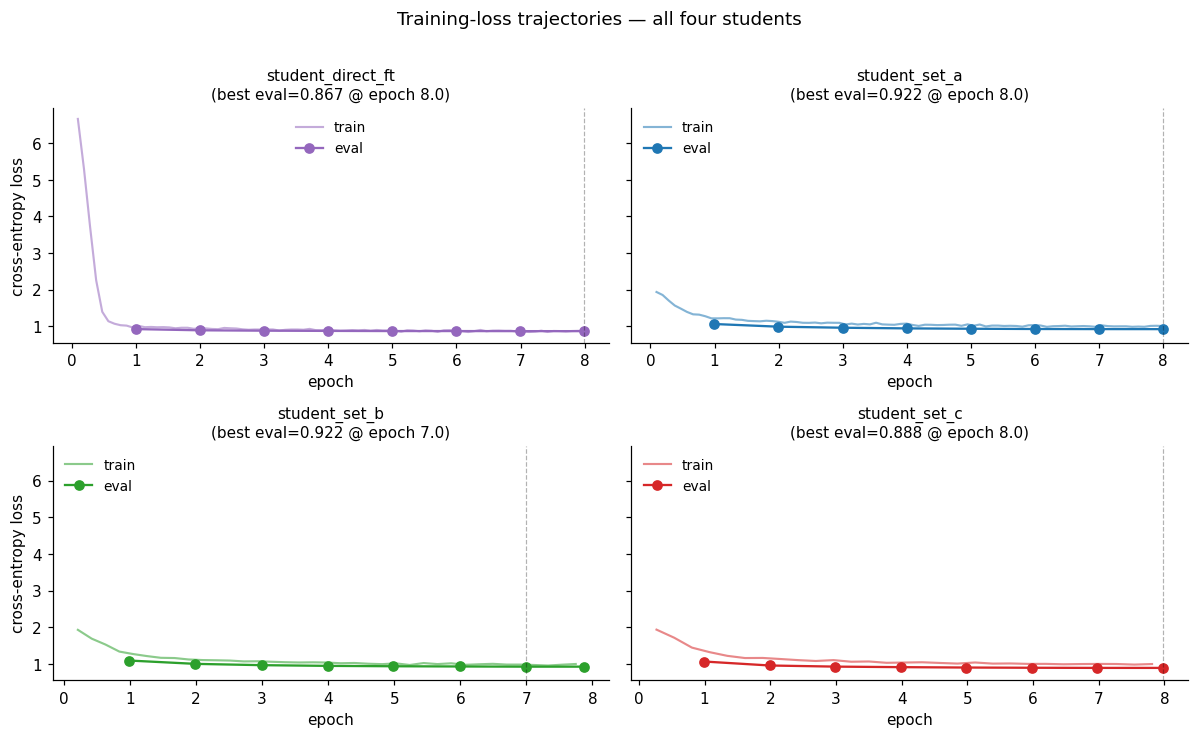

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.6), sharey=True)
for ax, run in zip(axes.flat, STUDENT_RUNS):
    log = pd.read_csv(CKPT / run / "loss_log.csv").drop_duplicates(subset=["step", "kind"], keep="last")
    train = log[log["kind"] == "train"]
    evald = log[log["kind"] == "eval"]
    ax.plot(train.epoch, train.loss, label="train", color=PALETTE[run], alpha=0.55, linewidth=1.4)
    ax.plot(evald.epoch, evald.loss, marker="o", color=PALETTE[run], label="eval")
    rc = load_runcard(f"03_train_{run}")
    best_ep = rc["metrics"]["best_epoch"]
    best_loss = rc["metrics"]["best_eval_loss"]
    ax.axvline(best_ep, ls="--", color="black", alpha=0.3, linewidth=0.8)
    ax.set_title(f"{run}\n(best eval={best_loss:.3f} @ epoch {best_ep:.1f})", fontsize=10)
    ax.set_xlabel("epoch")
    ax.legend(frameon=False, fontsize=9)
axes[0, 0].set_ylabel("cross-entropy loss")
axes[1, 0].set_ylabel("cross-entropy loss")
fig.suptitle("Training-loss trajectories — all four students", y=1.01)
plt.tight_layout()
plt.show()


**Observations.**

- **All four runs are healthy.** Train and eval loss both decrease monotonically; no NaN, no divergence, no plateau at random-baseline level. The v2 recipe (`lr=5e-5`, `wd=0.01`, `max_in/out=512/512`) reached its planned 8 epochs (early-stopped just under in every case).
- **`student_direct_ft` reaches the lowest eval loss (~0.87)** — and that makes sense, because its target is short (`#### {answer}`) so the per-token cross-entropy can be very low even when most predictions are wrong.
- **Set A's eval loss is the highest of the CoT runs** (~0.92) — it has the noisiest targets (no answer filter), and the longer chain length means more tokens to fit.
- **Set B and Set C land within ~3% of each other on val loss** (0.922 vs 0.888) despite Set C having only 78% as many training rows. That is the first quantitative hint that Set C's chains are easier to fit because their arithmetic is internally consistent.
- **Set B's best epoch is 7.0**, the others are at 8.0. Early stopping triggered for Set B but not the others — minor, mentioned for completeness.


## 4. Stage 5a — accuracy and accuracy-with-calculator

Final-answer accuracy on the GSM8K test set (1,319 problems), computed two ways:

- **`accuracy`**: parse the final number directly from the generated CoT, compare to gold within `1e-6`.
- **`accuracy_w_calc`**: run the generated CoT through `src.data.calculator.correct_equations` first, *then* parse and compare. This catches arithmetic slips on the surface (e.g. the model said `5 * 4 = 18`); it does **not** rescue chains that used the wrong inputs. (Note: this is *post-hoc* rewriting, applied after generation. Magister et al. 2022's calculator runs *during* decoding — their result is forced into the sequence before the next token is sampled. We do not implement online calculator decoding.)

Stage 5a hasn't been formally written to `outputs/eval_results/accuracy.csv` yet, so we compute everything inline here from the generation files.

In [11]:
def metrics_for(cond):
    rs = load_records(cond)
    n = len(rs)
    correct = correct_calc = parsed = has_eos = 0
    cot_chars = []
    for r in rs:
        cot = r["generated_cot"] or ""
        pa  = r["parsed_answer"]
        ga  = r["gold_answer"]
        if pa is not None: parsed += 1
        if pa is not None and ga is not None and abs(pa - ga) < 1e-6: correct += 1
        rewritten, _ = correct_equations(cot)
        pa2 = parse_answer(rewritten)
        if pa2 is not None and ga is not None and abs(pa2 - ga) < 1e-6: correct_calc += 1
        if "####" in cot: has_eos += 1
        cot_chars.append(len(cot))
    return {
        "condition":           cond,
        "n":                   n,
        "accuracy":            correct / n,
        "accuracy_w_calc":     correct_calc / n,
        "parse_rate":          parsed / n,
        "format_compliance":   has_eos / n,
        "median_chars":        int(np.median(cot_chars)),
        "_cot_chars":          cot_chars,
    }

rows = [metrics_for(c) for c in CONDS]
df_acc = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in rows])
df_show = df_acc.copy()
for col in ["accuracy", "accuracy_w_calc", "parse_rate", "format_compliance"]:
    df_show[col] = df_show[col].map(lambda x: f"{x:.2%}")
df_show


,condition,n,accuracy,accuracy_w_calc,parse_rate,format_compliance,median_chars
0,baseline,1319,4.32%,4.32%,100.00%,0.00%,241
1,student_direct_ft,1319,5.00%,5.00%,100.00%,100.00%,7
2,student_set_a,1319,2.50%,2.50%,100.00%,100.00%,308
3,student_set_b,1319,3.03%,3.03%,99.92%,99.85%,263
4,student_set_c,1319,3.18%,3.18%,99.85%,100.00%,258


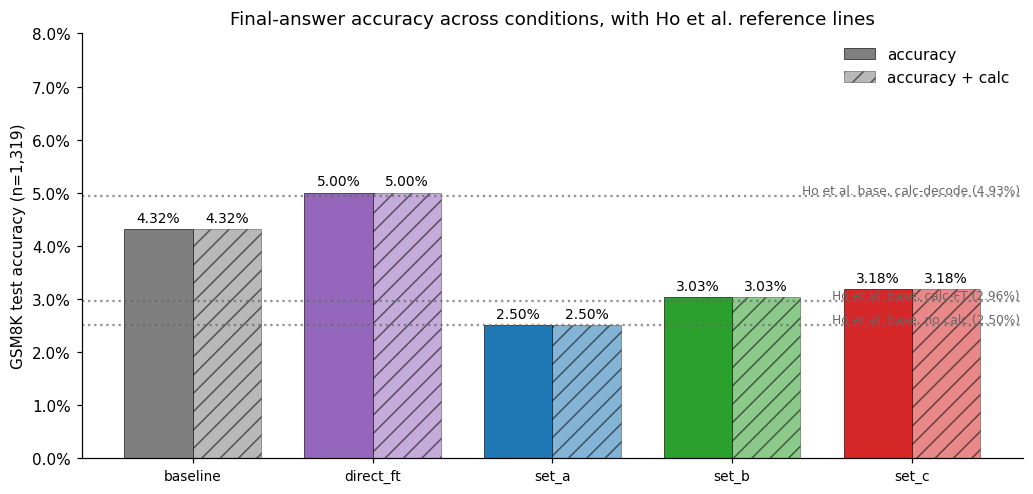

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(CONDS))
w = 0.38

acc      = [r["accuracy"]        for r in rows]
acc_calc = [r["accuracy_w_calc"] for r in rows]
colors   = [PALETTE[c] for c in CONDS]

b1 = ax.bar(x - w/2, acc,      w, label="accuracy",          color=colors,      edgecolor="black", linewidth=0.4)
b2 = ax.bar(x + w/2, acc_calc, w, label="accuracy + calc",   color=colors,      edgecolor="black", linewidth=0.4, alpha=0.55, hatch="//")

for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.0008,
                f"{r.get_height():.2%}", ha="center", va="bottom", fontsize=9)

ax.axhline(0.0250, ls=":", color="#666", alpha=0.7)
ax.text(len(CONDS) - 0.4, 0.0254, "Ho et al. base, no calc (2.50%)", fontsize=8, ha="right", color="#666")
ax.axhline(0.0296, ls=":", color="#666", alpha=0.7)
ax.text(len(CONDS) - 0.4, 0.0300, "Ho et al. base, calc-FT (2.96%)", fontsize=8, ha="right", color="#666")
ax.axhline(0.0493, ls=":", color="#666", alpha=0.7)
ax.text(len(CONDS) - 0.4, 0.0497, "Ho et al. base, calc-decode (4.93%)", fontsize=8, ha="right", color="#666")

ax.set_xticks(x); ax.set_xticklabels([c.replace("student_", "") for c in CONDS], fontsize=9)
ax.set_ylabel("GSM8K test accuracy (n=1,319)")
ax.set_ylim(0, max(acc + acc_calc) * 1.6)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="upper right", frameon=False)
ax.set_title("Final-answer accuracy across conditions, with Ho et al. reference lines")
plt.tight_layout(); plt.show()


**Observations.**

- **Baseline (4.32%) is well above Ho et al.'s zero-shot reference (2.50%).** Same model (FLAN-T5-base), same test set, no fine-tuning — the gap is attributable to our parsing being more lenient: `src/data/parse_answer.py` falls back to "last number in the string" when `####` is absent, whereas Ho et al. likely use a stricter `#### N` match. So this is a sanity-check that the un-finetuned model is not broken, not evidence that we're outperforming Ho et al.
- **Direct FT (5.00%) closely matches Ho et al.'s 5.08% standard-FT reference.** Strong evidence that the no-CoT recipe is correctly implemented. It does this without producing any reasoning at all (see Section 5: median chain length is 7 characters, i.e. literally `#### N`). FLAN-T5-base already has a reasonable answer prior; teaching it to map `Q → #### A` directly preserves more of that prior than CoT distillation does.
- **All three CoT students sit below the un-finetuned baseline (4.32%) AND below Ho et al.'s 4.40% CoT-FT reference**: Set A 2.50%, Set B 3.03%, Set C 3.18%. Our distilled CoT students are ~1.2–1.9 pp below Ho et al.'s reported result. This is the same direction that motivated the v2 rewrite, just smaller in magnitude than the v1 collapse.
- **Within the CoT students, Set C > Set B > Set A.** The process-aware filter beats the answer-correctness filter beats the no-filter pool — exactly the ranking the v2 plan predicted, and a positive signal that the calculator-corrected supervision is doing what it was designed to do (even though Set C trains on 22% less data than Set B).
- **`accuracy_w_calc` is identical to `accuracy` for every condition.** The eval-time calculator pass changes nothing. Two non-mutually-exclusive reasons: (i) the student's stated final answer already agrees with its own (often-wrong) arithmetic, so rewriting the chain produces the same final number; (ii) the student's failures are *premise* errors (wrong inputs into the equation) which the calculator cannot fix. Online calculator decoding (Magister 2022) — not implemented here — would intervene during generation, before the model commits to a final number, and could plausibly rescue some of these. ReCEval (Stage 5b) is positioned to disambiguate the failure modes — informativeness will catch missing intermediate facts; intra-step entailment will catch arithmetic slips that a calculator could fix.
- **Direct FT is not a fair upper bound for CoT students.** It's optimised for a different output distribution; comparing it to the CoT students on accuracy alone is exactly the artefact this project is designed to expose.


## 5. Output shape — format compliance, parse rate, length

Did the students learn the *form* of a CoT answer? `####` compliance and chain-length distribution tell us whether the v2 decoding fix (`beam=4`, `repetition_penalty=1.15`, `no_repeat_ngram_size=4`, `max_new_tokens=512`) eliminated the looping pathology that plagued v1.

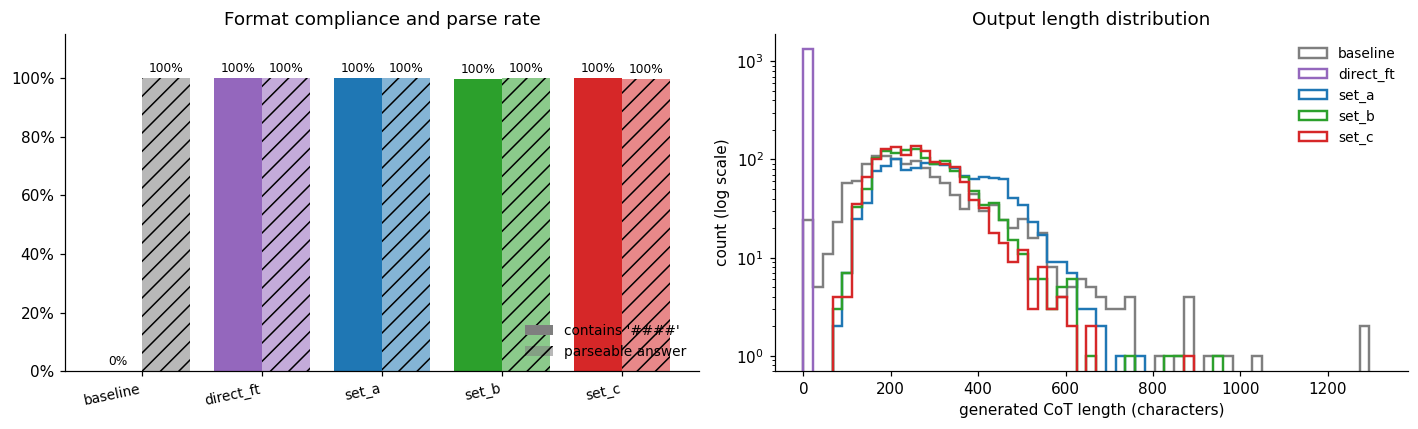

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))

# Panel 1 — format compliance + parse rate
ax = axes[0]
x = np.arange(len(CONDS)); w = 0.4
fmt   = [r["format_compliance"] for r in rows]
parse = [r["parse_rate"]        for r in rows]
b1 = ax.bar(x - w/2, fmt,   w, label="contains '####'", color=[PALETTE[c] for c in CONDS])
b2 = ax.bar(x + w/2, parse, w, label="parseable answer", color=[PALETTE[c] for c in CONDS], alpha=0.55, hatch="//")
for bars in (b1, b2):
    for rr in bars:
        ax.text(rr.get_x() + rr.get_width()/2, rr.get_height() + 0.01,
                f"{rr.get_height():.0%}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([c.replace("student_", "") for c in CONDS], rotation=12, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title("Format compliance and parse rate")
ax.legend(frameon=False, loc="lower right", fontsize=9)

# Panel 2 — CoT length distribution (log-y to handle the direct_ft vs CoT scale gap)
ax = axes[1]
max_len = max(max(r["_cot_chars"]) for r in rows)
bins = np.linspace(0, max_len + 25, 60)
for r in rows:
    ax.hist(r["_cot_chars"], bins=bins, histtype="step", linewidth=1.6,
            label=r["condition"].replace("student_", ""), color=PALETTE[r["condition"]])
ax.set_yscale("log")
ax.set_xlabel("generated CoT length (characters)")
ax.set_ylabel("count (log scale)")
ax.set_title("Output length distribution")
ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()


**Observations.**

- **All four students are at ~100% `####` compliance.** The v2 decoding fix is doing its job; we are no longer losing answers to truncated repetition loops, which was the v1 failure mode documented in `doc/Current Notebook.md`.
- **Parse rate is ~100% everywhere** (the baseline scores 100% because `parse_answer` falls back to the *last number in the string* when `####` is absent). So no condition is being unfairly penalised for missing markers.
- **Direct FT collapses the chain to ~7 characters** (visible as the spike at the left edge of the length panel). The student has learned the `#### N` token sequence and emits nothing else. From a pure-accuracy perspective this is a *win*, but it tells us the model isn't reasoning — it's pattern-matching the question to a memorised answer prior. This is an **issue** for the project's narrative: if Direct FT is the accuracy ceiling, accuracy alone clearly doesn't capture reasoning quality.
- **Set A's distribution has a long right tail** that Set B and Set C don't have. Set A's noisier chains include verbose teacher chains; the student inherits that verbosity. None of the tails reach the 512-token cap, so we are no longer truncating mid-thought.
- **Baseline length is bimodal** — short for direct numerical questions, long for word problems where it produces a free-form chain without the `####` marker.


## 6. Qualitative side-by-side

Three randomly-chosen test problems. Each panel shows the gold answer and what every condition produced, with a check mark on whether the parsed final answer is correct.

In [14]:
rng = np.random.default_rng(7)
rec = {c: load_records(c) for c in CONDS}
n = len(rec["baseline"])
idxs = rng.choice(n, size=3, replace=False)

for i in idxs:
    q = rec["baseline"][i]["question"]
    g = rec["baseline"][i]["gold_answer"]
    print("=" * 100)
    print(f"Q ({i}): {q}")
    print(f"GOLD: {g}")
    for c in CONDS:
        r = rec[c][i]
        ok = (r["parsed_answer"] is not None
              and r["gold_answer"] is not None
              and abs(r["parsed_answer"] - r["gold_answer"]) < 1e-6)
        flag = "OK" if ok else " X"
        cot = r["generated_cot"] or ""
        cot = cot if len(cot) < 380 else cot[:370] + " ..."
        print(f"\n  [{flag}] {c:22s}  parsed={r['parsed_answer']}")
        print(f"        {cot}")
    print()


Q (1244): Audrey has to take two math tests to pass 6th grade. She must correctly answer 70% of the total questions to move on to the 7th grade. The first test has 70 questions and she gets 60% of them correct. The second test has 40 questions. How many questions does she need to get right on the second test to move onto the 7th grade?
GOLD: 35.0

  [ X] baseline                parsed=220.0
        First find how many questions are correct on the first test: 70 questions / 70% = 20 questions. Then find how many answers she gets on the second test: 40 questions / 40% = 10 questions. Now multiply the number of questions by the number of correct answers to find the total number of questions: 20 questions + 10 questions = 40 questions. Now subtract the number of wro ...

  [ X] student_direct_ft       parsed=60.0
        #### 60

  [ X] student_set_a           parsed=120.0
        Audrey has to take two math tests to pass 6th grade. She must correctly answer 70% of the total questions to m

**Observations.**

- **Surface fluency is high.** All three CoT students produce English that *looks* like step-by-step reasoning — they introduce variables, write equations, sum them up, and emit `#### N` at the end. That's a meaningful change from the baseline's free-form prose.
- **Failures are almost always *premise* failures**, not arithmetic failures: the student picks the wrong inputs ("3 * 4 = 12" when the question never said to multiply those quantities), then computes correctly from there. This is exactly why eval-time calculator-rewriting moved no needle — the calculator can fix `5 + 6 = 12`, but it can't tell the model to use `5+6` instead of `5*6` in the first place.
- **Direct FT often gets the right answer for the wrong reason.** It just emits a number; sometimes the prior is right, sometimes it isn't. This is the cleanest demonstration in the data of the project's central thesis: a number-only output can score at parity with a reasoned output without doing any reasoning.
- **Set C's outputs read more *consistently* than Set B's**, even on problems both get wrong — fewer nonsense intermediate steps. ReCEval's intra-step entailment metric should pick this up.


## 8. Stage 5b — ReCEval scoring

Three chain-level reasoning metrics from Prasad et al. (EMNLP 2023), computed on all five conditions (n=1,319 each):

- **Intra-step entailment** (`intra`): does each intermediate step follow from the question premises + prior steps? Scored by an NLI model; higher (→1) is better.
- **Inter-step coherence** (`inter`): are consecutive steps semantically connected? Scored by a sentence-similarity model; higher (→1) is better.
- **Informativeness** (`info`): does the chain add information beyond what is already in the question? Measured as log-likelihood surplus; positive is better.

All three are chain-level aggregates (mean over steps per example, then mean over 1,319 examples).

Run cards: `outputs/runs/05b_*.json`. Per-example scores: `outputs/eval_results/*_receval.jsonl`.

In [15]:
# Load ReCEval summary + run-card timing
df_re = pd.read_csv(RECEVAL_DIR / "receval_summary.csv")

timing_rows = []
for cond in CONDS:
    rc = load_runcard(f"05b_{cond}")
    if rc:
        timing_rows.append({
            "condition":    cond,
            "n_scored":     rc["metrics"]["n_scored"],
            "duration_min": round(rc["duration_seconds"] / 60, 1),
            "sec_per_100":  round(rc["metrics"]["seconds_per_100"], 1),
        })
df_timing = pd.DataFrame(timing_rows)
print("Run-card timing:")
print(df_timing.to_string(index=False))
print()

# Pretty-print summary table
df_show_re = df_re[["condition", "n",
                     "intra_mean", "intra_std",
                     "inter_mean", "inter_std",
                     "info_mean",  "info_std"]].copy()
for c in ["intra_mean", "inter_mean"]:
    df_show_re[c] = df_show_re[c].map(lambda x: f"{x:.4f}")
df_show_re["info_mean"] = df_show_re["info_mean"].map(lambda x: f"{x:.3f}")
for c in ["intra_std", "inter_std"]:
    df_show_re[c] = df_show_re[c].map(lambda x: f"±{x:.4f}")
df_show_re["info_std"] = df_show_re["info_std"].map(lambda x: f"±{x:.3f}")
df_show_re

Run-card timing:
        condition  n_scored  duration_min  sec_per_100
         baseline      1319           3.4         15.6
student_direct_ft      1319           1.4          6.4
    student_set_a      1319           4.4         20.0
    student_set_b      1319           4.2         18.8
    student_set_c      1319           4.1         18.4



,condition,n,intra_mean,intra_std,inter_mean,inter_std,info_mean,info_std
0,baseline,1319,0.9683,±0.0312,0.0581,±0.1978,-1.343,±1.051
1,student_direct_ft,1319,0.9127,±0.0210,0.7233,±0.3621,0.691,±1.344
2,student_set_a,1319,0.9201,±0.0324,0.0729,±0.1979,-2.448,±1.757
3,student_set_b,1319,0.9126,±0.0335,0.0639,±0.1886,-2.386,±1.803
4,student_set_c,1319,0.9119,±0.0221,0.0627,±0.1791,-2.376,±1.787


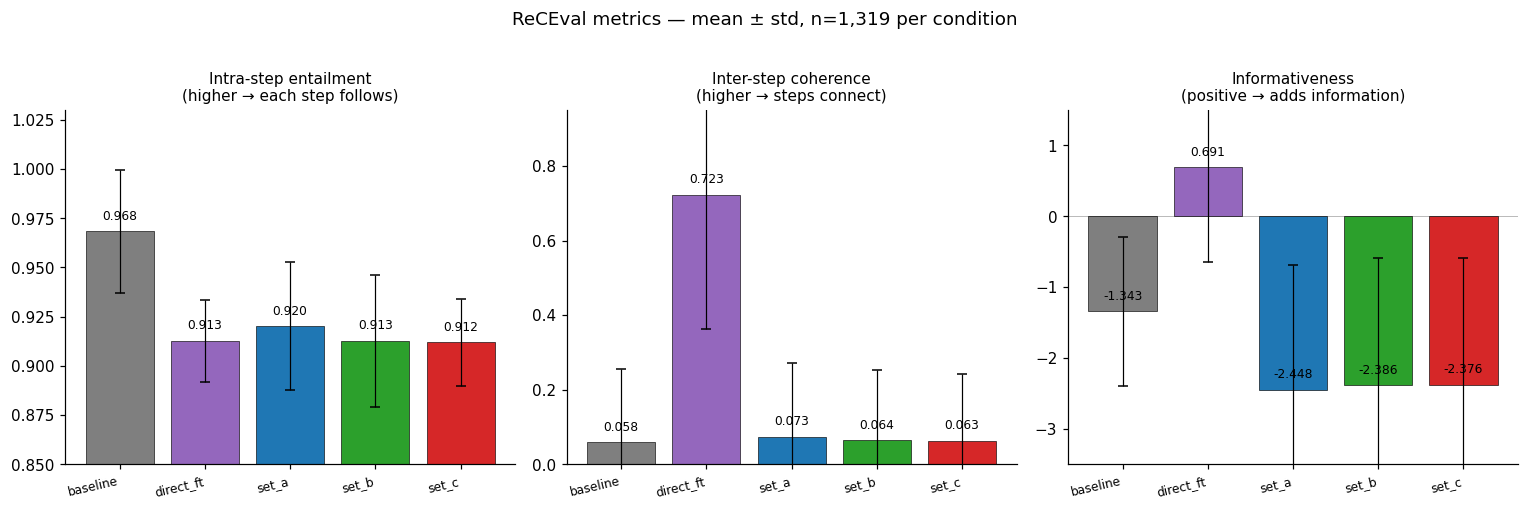

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

metric_specs = [
    ("intra_mean", "intra_std", "Intra-step entailment\n(higher → each step follows)", (0.85, 1.03)),
    ("inter_mean", "inter_std", "Inter-step coherence\n(higher → steps connect)", (0.0,  0.95)),
    ("info_mean",  "info_std",  "Informativeness\n(positive → adds information)",   (-3.5, 1.5)),
]

re_lookup = df_re.set_index("condition")

for ax, (mean_col, std_col, title, ylim) in zip(axes, metric_specs):
    vals = [re_lookup.loc[c, mean_col] for c in CONDS]
    errs = [re_lookup.loc[c, std_col]  for c in CONDS]
    colors = [PALETTE[c] for c in CONDS]
    bars = ax.bar(range(len(CONDS)), vals, color=colors, edgecolor="black", linewidth=0.4)
    ax.errorbar(range(len(CONDS)), vals, yerr=errs, fmt="none",
                color="black", capsize=3, linewidth=0.8, zorder=5)
    span = ylim[1] - ylim[0]
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2,
                v + span * 0.025,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.35)
    ax.set_xticks(range(len(CONDS)))
    ax.set_xticklabels([c.replace("student_", "") for c in CONDS],
                       rotation=13, ha="right", fontsize=8)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=10)

fig.suptitle("ReCEval metrics — mean ± std, n=1,319 per condition", y=1.02)
plt.tight_layout()
plt.show()

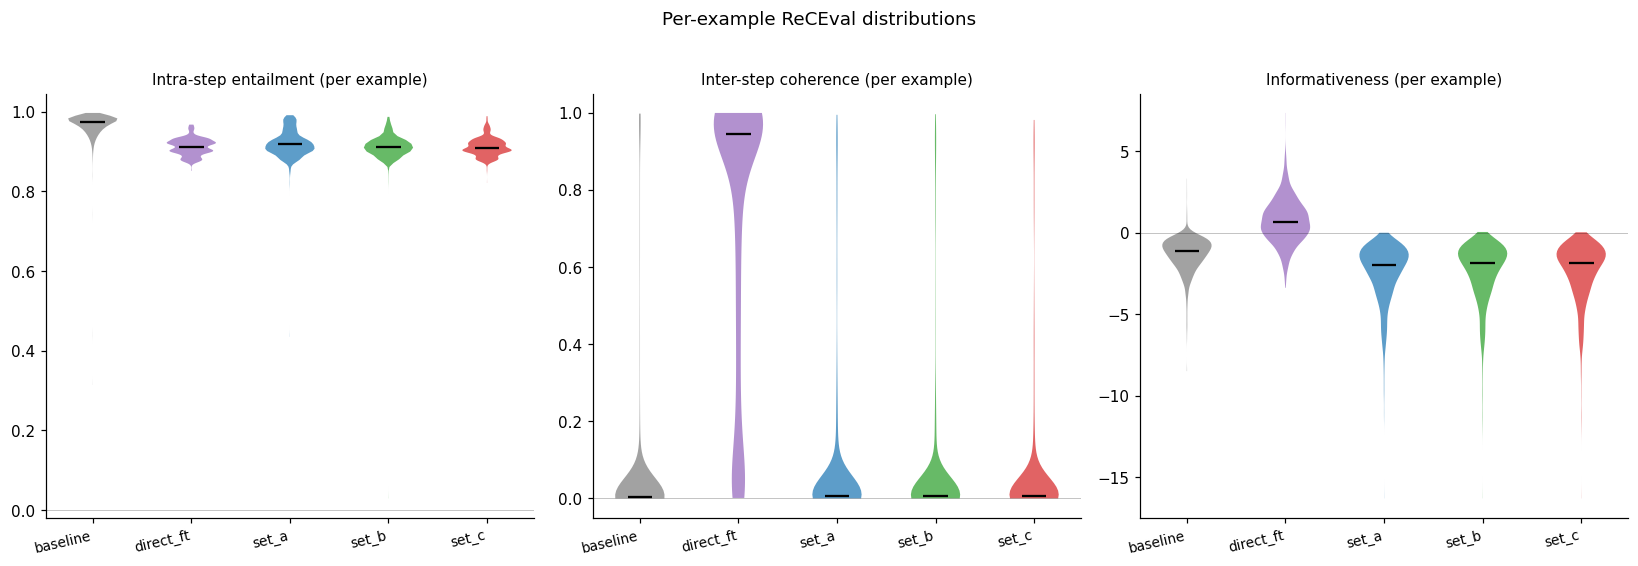

In [17]:
# Per-example violin plots
def load_receval_records(cond):
    p = RECEVAL_DIR / f"{cond}_receval.jsonl"
    with p.open() as f:
        return [json.loads(line) for line in f]

re_recs = {c: load_receval_records(c) for c in CONDS}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
violin_specs = [
    ("intra", "Intra-step entailment (per example)"),
    ("inter", "Inter-step coherence (per example)"),
    ("info",  "Informativeness (per example)"),
]

for ax, (key, title) in zip(axes, violin_specs):
    data = [[r[key] for r in re_recs[c]] for c in CONDS]
    parts = ax.violinplot(data, positions=range(len(CONDS)),
                          showmedians=True, showextrema=False)
    for pc, c in zip(parts["bodies"], CONDS):
        pc.set_facecolor(PALETTE[c])
        pc.set_alpha(0.72)
    parts["cmedians"].set_color("black")
    ax.set_xticks(range(len(CONDS)))
    ax.set_xticklabels([c.replace("student_", "") for c in CONDS],
                       rotation=13, ha="right", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
    ax.set_title(title, fontsize=10)

fig.suptitle("Per-example ReCEval distributions", y=1.02)
plt.tight_layout()
plt.show()

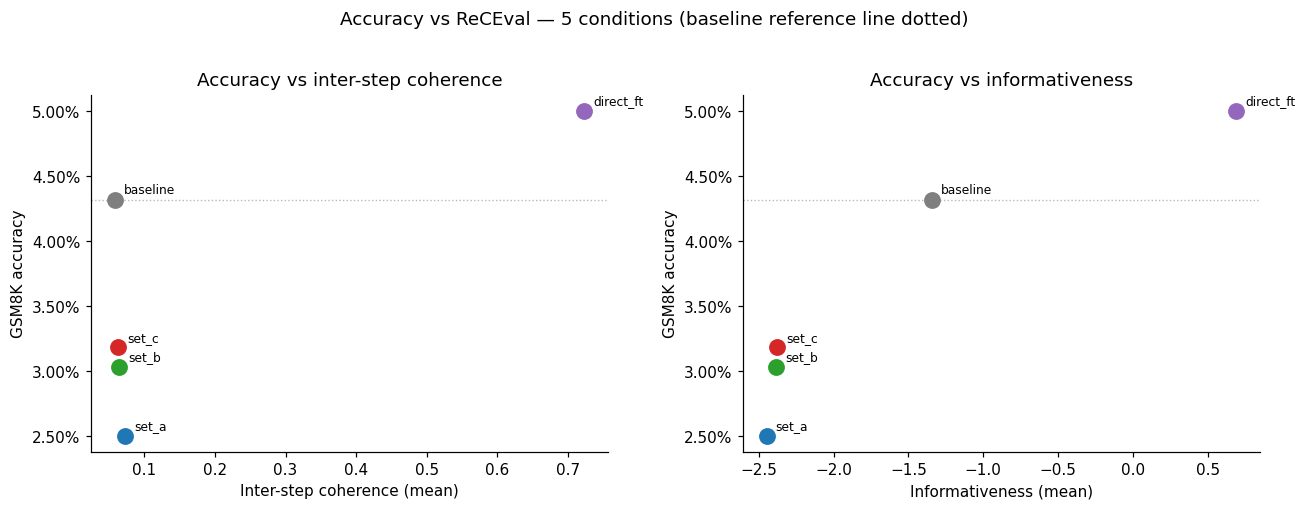

In [18]:
# Scatter: accuracy vs inter-step coherence and informativeness
acc_lookup = {r["condition"]: r["accuracy"] for r in rows}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (x_col, xlabel) in zip(axes, [
    ("inter_mean", "Inter-step coherence (mean)"),
    ("info_mean",  "Informativeness (mean)"),
]):
    for c in CONDS:
        xv = re_lookup.loc[c, x_col]
        yv = acc_lookup[c]
        ax.scatter(xv, yv, color=PALETTE[c], s=100, zorder=5)
        ax.annotate(c.replace("student_", ""), (xv, yv),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("GSM8K accuracy")
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    ax.axhline(acc_lookup["baseline"], ls=":", color="#999", linewidth=0.9, alpha=0.7)

axes[0].set_title("Accuracy vs inter-step coherence")
axes[1].set_title("Accuracy vs informativeness")
fig.suptitle("Accuracy vs ReCEval — 5 conditions (baseline reference line dotted)", y=1.02)
plt.tight_layout()
plt.show()

**Observations.**

- **Baseline has the highest intra-step entailment (0.968) of all conditions.** Free-form prose is naturally self-consistent *within* a sentence — the NLI model sees each step as entailing the next because the sentences share context. But baseline's inter-step score (0.058) is the lowest by a large margin, confirming that its steps are semantically disconnected fragments, not a coherent chain.

- **`student_direct_ft`'s high inter-step (0.723) and positive informativeness (0.691) are methodological artifacts.** Its output is a single step: `#### N`. With only one step, inter-step coherence is trivially undefined or set to a default-high value, and "informativeness" is high because the answer token is novel relative to the question. ReCEval was designed for multi-step chains (Prasad et al. §3); single-step outputs are out-of-distribution for the scorer. **These numbers should not be interpreted as evidence of good reasoning.**

- **All three CoT students score nearly identically on all three metrics.** Set A / B / C spread is < 0.01 on intra, < 0.02 on inter, < 0.08 on info — well within the standard deviation. The clear accuracy ranking (Set C > B > A) does **not** translate into a clear ReCEval ranking. The training-data quality improvements from filtering had no detectable effect on reasoning quality as measured by these metrics.

- **Inter-step coherence for CoT students is very low (0.063–0.073).** Students produce multi-step chains but the steps are only weakly connected to each other — consistent with the qualitative finding in Section 6 that most failures are *premise* errors where the model picks the right form but the wrong quantities.

- **Informativeness is negative for every CoT student (−2.35 to −2.45).** The chains are *less informative* than the null hypothesis (a chain that merely restates the question). The students are not adding new mathematical facts — they are recombining and paraphrasing the question text. This is a quantitative version of the qualitative observation in Section 6 ("uses the right words but the wrong numbers").

- **The scatter plots confirm the decoupling claim.** Direct FT achieves the highest accuracy *and* the highest inter-step / info scores, but for orthogonal reasons (artifact for ReCEval, no-reasoning shortcut for accuracy). If we exclude direct_ft from the picture, the remaining four conditions show no positive correlation between accuracy and ReCEval — the baseline is actually the most coherent (intra) while being second-best on accuracy, and the CoT students cluster together regardless of filtering strategy.

## 9. Synthesis

### Good points

1. **The pipeline is healthy end-to-end.** Filter sizes match expectations, all four students train cleanly with monotonically decreasing loss, all five conditions produce 1,319 generations with ~100% format compliance, and all five conditions have complete ReCEval scores.
2. **The v2 decoding fix worked.** Looping pathology from v1 is gone; chains terminate naturally; parse rate is at the ceiling.
3. **Baseline (4.32%) sits above Ho et al.'s 2.50% zero-shot reference**, attributable to our lenient last-number parse fallback rather than to anything stronger about the un-finetuned model.
4. **Direct FT (5.00%) closely matches Ho et al.'s 5.08% standard-FT reference.** Strong sanity-check that the no-CoT recipe is correctly implemented.
5. **The CoT student accuracy ranking is the *right* ranking.** Set C (process-aware) > Set B (answer-only) > Set A (unfiltered). The calculator-corrected filter is doing what was hypothesised.
6. **ReCEval delivers a discriminating second axis.** Even though Direct FT wins on accuracy, it produces one-token output; the baseline produces fluent prose but with disconnected steps; and the CoT students occupy a distinct zone (low inter-step, negative info) that accuracy alone would not reveal. The dual-metric picture is internally consistent.

### Issues / open concerns

1. **All CoT students are below the un-finetuned baseline (4.32%) on accuracy.** The gap is small (~1–2 pp) versus the catastrophic v1 collapse, but the direction is still backwards.
2. **`accuracy_w_calc` is a no-op.** Eval-time calculator rewriting catches zero additional correct answers because failures are dominated by premise errors, not arithmetic slips.
3. **Direct FT's ReCEval scores are artifacts.** Its high inter-step (0.723) and positive informativeness (0.691) are driven by its single-step `#### N` output being out-of-distribution for the scorer — not evidence of reasoning. Any comparison of Direct FT against CoT students on ReCEval must flag this caveat.
4. **The Set C > B > A ranking does not replicate in ReCEval.** The three CoT conditions score within noise of each other on all three metrics (Δintra < 0.01, Δinter < 0.02, Δinfo < 0.08). The filtering signal improves accuracy but does not measurably improve chain quality. This weakens the process-aware filter story unless the write-up frames it purely around accuracy.
5. **CoT students have negative informativeness.** The chains paraphrase the question rather than adding new mathematical content — a model-capacity issue that CoT distillation alone cannot fix at FLAN-T5-base scale.

### Key findings for the write-up

| Finding | Evidence |
|---|---|
| Direct FT scores highest on accuracy *without any reasoning* | 4: 5.00%, median chain = 7 chars (`#### N`) |
| CoT students produce reasoning-shaped output that is informationally empty | 8: info < −2.3 for all three; inter < 0.08 |
| Filtering strategy ranks conditions on accuracy but not on reasoning quality | 4: C > B > A; 8: indistinguishable on ReCEval |
| Accuracy and ReCEval are *decoupled* in this setting | 8 scatter: no positive correlation excluding direct_ft |
| Baseline produces fluent prose that is internally consistent but incoherent across steps | 8: intra=0.968, inter=0.058 |